In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Loading the dataset**

In [2]:
import pandas as pd
import numpy as np

file_path = '/content/drive/MyDrive/eICU/eICU_Dataset.csv'
df = pd.read_csv(file_path)

print("Dataset loaded successfully.")
print("Shape of dataset:", df.shape)
df.head()

Dataset loaded successfully.
Shape of dataset: (12000, 40)


,patient_id,hospital_id,age,gender,ethnicity,bmi,admission_type,unit_type,prior_admissions_1yr,diabetes,...,vasopressor_used,dialysis_used,antibiotics_used,surgery_flag,icu_stay_days,hospital_stay_days,complications_count,mortality_risk_score,discharge_disposition,readmission_30d
0,1,7,73,Male,White,16.3,Urgent,CCU,1,1,...,0,0,0,1,1.8,11.9,1,6.49,Home,0
1,2,20,49,Male,Hispanic,19.3,Emergency,SICU,1,0,...,1,1,1,1,9.3,15.0,0,5.28,Home,1
2,3,15,83,Female,Black,37.7,Emergency,CCU,1,1,...,0,0,0,0,3.0,13.1,2,6.75,Home Health,1
3,4,11,64,Female,White,27.9,Emergency,CCU,1,0,...,0,0,0,0,2.4,8.4,3,7.23,Home,1
4,5,8,52,Female,White,16.2,Emergency,CCU,1,0,...,0,0,1,0,4.8,10.0,0,2.40,Rehab,0


In [3]:
print("Full column list:\n")
print(df.columns.tolist())

print("\nData types:\n")
print(df.dtypes)

Full column list:

['patient_id', 'hospital_id', 'age', 'gender', 'ethnicity', 'bmi', 'admission_type', 'unit_type', 'prior_admissions_1yr', 'diabetes', 'hypertension', 'cad', 'ckd', 'copd', 'sepsis_history', 'heart_rate_mean', 'systolic_bp_mean', 'respiratory_rate_mean', 'spo2_mean', 'temperature_mean', 'glucose_mean', 'creatinine', 'bun', 'sodium', 'potassium', 'hemoglobin', 'wbc', 'platelets', 'insulin_used', 'ventilator_used', 'vasopressor_used', 'dialysis_used', 'antibiotics_used', 'surgery_flag', 'icu_stay_days', 'hospital_stay_days', 'complications_count', 'mortality_risk_score', 'discharge_disposition', 'readmission_30d']

Data types:

patient_id                 int64
hospital_id                int64
age                        int64
gender                    object
ethnicity                 object
bmi                      float64
admission_type            object
unit_type                 object
prior_admissions_1yr       int64
diabetes                   int64
hypertension      

In [4]:
print("Missing values per column:\n")
print(df.isnull().sum())

print("\nTotal missing values in dataset:", df.isnull().sum().sum())

print("\nNumber of duplicate rows:", df.duplicated().sum())

Missing values per column:

patient_id               0
hospital_id              0
age                      0
gender                   0
ethnicity                0
bmi                      0
admission_type           0
unit_type                0
prior_admissions_1yr     0
diabetes                 0
hypertension             0
cad                      0
ckd                      0
copd                     0
sepsis_history           0
heart_rate_mean          0
systolic_bp_mean         0
respiratory_rate_mean    0
spo2_mean                0
temperature_mean         0
glucose_mean             0
creatinine               0
bun                      0
sodium                   0
potassium                0
hemoglobin               0
wbc                      0
platelets                0
insulin_used             0
ventilator_used          0
vasopressor_used         0
dialysis_used            0
antibiotics_used         0
surgery_flag             0
icu_stay_days            0
hospital_stay_days       0


In [5]:
print("Target column distribution:\n")
print(df['readmission_30d'].value_counts())

print("\nTarget column percentage distribution:\n")
print(df['readmission_30d'].value_counts(normalize=True) * 100)

Target column distribution:

readmission_30d
0    8923
1    3077
Name: count, dtype: int64

Target column percentage distribution:

readmission_30d
0    74.358333
1    25.641667
Name: proportion, dtype: float64


In [6]:
print("Numerical summary:\n")
display(df.describe())

print("\nCategorical summary:\n")
display(df.describe(include='object'))

Numerical summary:



,patient_id,hospital_id,age,bmi,prior_admissions_1yr,diabetes,hypertension,cad,ckd,copd,...,ventilator_used,vasopressor_used,dialysis_used,antibiotics_used,surgery_flag,icu_stay_days,hospital_stay_days,complications_count,mortality_risk_score,readmission_30d
count,12000.00000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,...,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000
mean,6000.50000,10.556083,62.029000,28.136450,1.194917,0.524083,0.669500,0.455833,0.419833,0.334167,...,0.240750,0.190500,0.194333,0.618083,0.217250,5.050367,11.430725,0.530500,4.672739,0.256417
std,3464.24595,5.763357,14.527224,5.879454,1.086595,0.499440,0.470413,0.498066,0.493552,0.471718,...,0.427557,0.392712,0.395703,0.485877,0.412391,2.817638,4.623383,0.730147,1.860909,0.436673
min,1.00000,1.000000,18.000000,16.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000
25%,3000.75000,6.000000,52.000000,24.100000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,8.100000,0.000000,3.360000,0.000000
50%,6000.50000,11.000000,62.000000,28.100000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,4.500000,10.700000,0.000000,4.630000,0.000000
75%,9000.25000,16.000000,72.000000,32.200000,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,6.500000,14.100000,1.000000,5.952500,1.000000
max,12000.00000,20.000000,90.000000,49.200000,7.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,24.900000,39.700000,6.000000,11.380000,1.000000



Categorical summary:



,gender,ethnicity,admission_type,unit_type,discharge_disposition
count,12000,12000,12000,12000,12000
unique,2,5,3,5,4
top,Male,White,Emergency,MICU,Home
freq,6763,6053,8128,4244,8413


**Data Preprocessing**

In [7]:
# Define target column
target_col = 'readmission_30d'

# Columns to remove from modelling
id_cols = ['patient_id', 'hospital_id']

# Create feature matrix X and target vector y
X = df.drop(columns=id_cols + [target_col])
y = df[target_col]

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

print("\nFirst 5 rows of features:")
display(X.head())

print("\nFirst 5 values of target:")
display(y.head())

Feature matrix shape: (12000, 37)
Target vector shape: (12000,)

First 5 rows of features:


,age,gender,ethnicity,bmi,admission_type,unit_type,prior_admissions_1yr,diabetes,hypertension,cad,...,ventilator_used,vasopressor_used,dialysis_used,antibiotics_used,surgery_flag,icu_stay_days,hospital_stay_days,complications_count,mortality_risk_score,discharge_disposition
0,73,Male,White,16.3,Urgent,CCU,1,1,1,1,...,0,0,0,0,1,1.8,11.9,1,6.49,Home
1,49,Male,Hispanic,19.3,Emergency,SICU,1,0,0,1,...,0,1,1,1,1,9.3,15.0,0,5.28,Home
2,83,Female,Black,37.7,Emergency,CCU,1,1,1,1,...,1,0,0,0,0,3.0,13.1,2,6.75,Home Health
3,64,Female,White,27.9,Emergency,CCU,1,0,1,1,...,1,0,0,0,0,2.4,8.4,3,7.23,Home
4,52,Female,White,16.2,Emergency,CCU,1,0,0,0,...,0,0,0,1,0,4.8,10.0,0,2.40,Rehab



First 5 values of target:


,readmission_30d
0,0
1,1
2,1
3,1
4,0


In [8]:
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("Categorical columns:")
print(categorical_cols)

print("\nNumber of categorical columns:", len(categorical_cols))

print("\nNumerical columns:")
print(numerical_cols)

print("\nNumber of numerical columns:", len(numerical_cols))

Categorical columns:
['gender', 'ethnicity', 'admission_type', 'unit_type', 'discharge_disposition']

Number of categorical columns: 5

Numerical columns:
['age', 'bmi', 'prior_admissions_1yr', 'diabetes', 'hypertension', 'cad', 'ckd', 'copd', 'sepsis_history', 'heart_rate_mean', 'systolic_bp_mean', 'respiratory_rate_mean', 'spo2_mean', 'temperature_mean', 'glucose_mean', 'creatinine', 'bun', 'sodium', 'potassium', 'hemoglobin', 'wbc', 'platelets', 'insulin_used', 'ventilator_used', 'vasopressor_used', 'dialysis_used', 'antibiotics_used', 'surgery_flag', 'icu_stay_days', 'hospital_stay_days', 'complications_count', 'mortality_risk_score']

Number of numerical columns: 32


In [9]:
# Create a clean dataframe for analysis
df_model = X.copy()
df_model[target_col] = y

print("Clean modelling dataframe shape:", df_model.shape)
display(df_model.head())

Clean modelling dataframe shape: (12000, 38)


,age,gender,ethnicity,bmi,admission_type,unit_type,prior_admissions_1yr,diabetes,hypertension,cad,...,vasopressor_used,dialysis_used,antibiotics_used,surgery_flag,icu_stay_days,hospital_stay_days,complications_count,mortality_risk_score,discharge_disposition,readmission_30d
0,73,Male,White,16.3,Urgent,CCU,1,1,1,1,...,0,0,0,1,1.8,11.9,1,6.49,Home,0
1,49,Male,Hispanic,19.3,Emergency,SICU,1,0,0,1,...,1,1,1,1,9.3,15.0,0,5.28,Home,1
2,83,Female,Black,37.7,Emergency,CCU,1,1,1,1,...,0,0,0,0,3.0,13.1,2,6.75,Home Health,1
3,64,Female,White,27.9,Emergency,CCU,1,0,1,1,...,0,0,0,0,2.4,8.4,3,7.23,Home,1
4,52,Female,White,16.2,Emergency,CCU,1,0,0,0,...,0,0,1,0,4.8,10.0,0,2.40,Rehab,0


**Exploratory Data Analysis (EDA)**

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (8, 5)
sns.set_style("whitegrid")

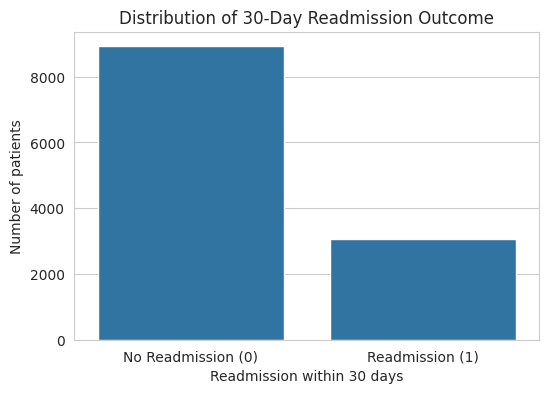

In [11]:
target_counts = df_model['readmission_30d'].value_counts().sort_index()

plt.figure(figsize=(6, 4))
sns.barplot(x=target_counts.index, y=target_counts.values)
plt.title("Distribution of 30-Day Readmission Outcome")
plt.xlabel("Readmission within 30 days")
plt.ylabel("Number of patients")
plt.xticks([0, 1], ['No Readmission (0)', 'Readmission (1)'])
plt.show()

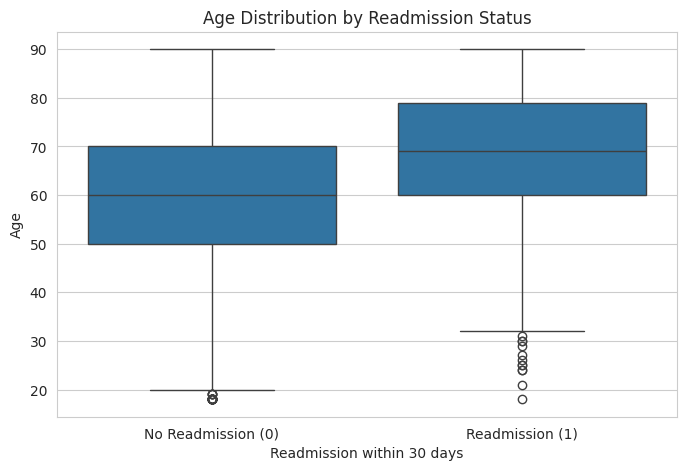

In [12]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='readmission_30d', y='age', data=df_model)
plt.title("Age Distribution by Readmission Status")
plt.xlabel("Readmission within 30 days")
plt.ylabel("Age")
plt.xticks([0, 1], ['No Readmission (0)', 'Readmission (1)'])
plt.show()

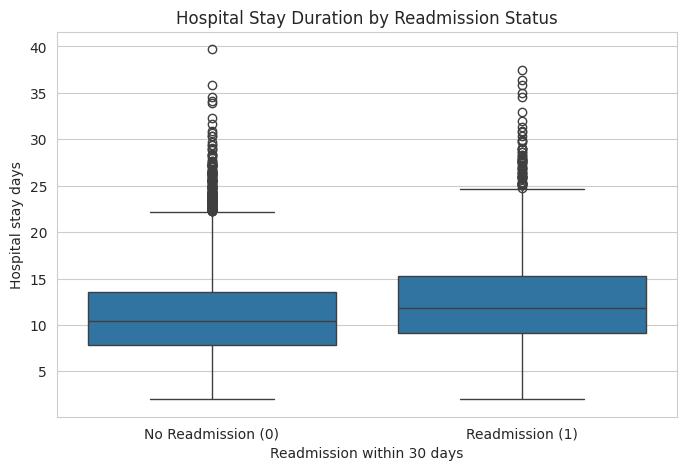

In [13]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='readmission_30d', y='hospital_stay_days', data=df_model)
plt.title("Hospital Stay Duration by Readmission Status")
plt.xlabel("Readmission within 30 days")
plt.ylabel("Hospital stay days")
plt.xticks([0, 1], ['No Readmission (0)', 'Readmission (1)'])
plt.show()

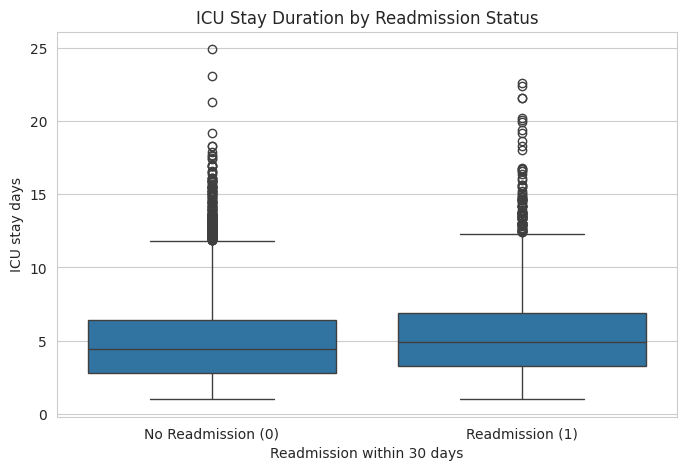

In [14]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='readmission_30d', y='icu_stay_days', data=df_model)
plt.title("ICU Stay Duration by Readmission Status")
plt.xlabel("Readmission within 30 days")
plt.ylabel("ICU stay days")
plt.xticks([0, 1], ['No Readmission (0)', 'Readmission (1)'])
plt.show()

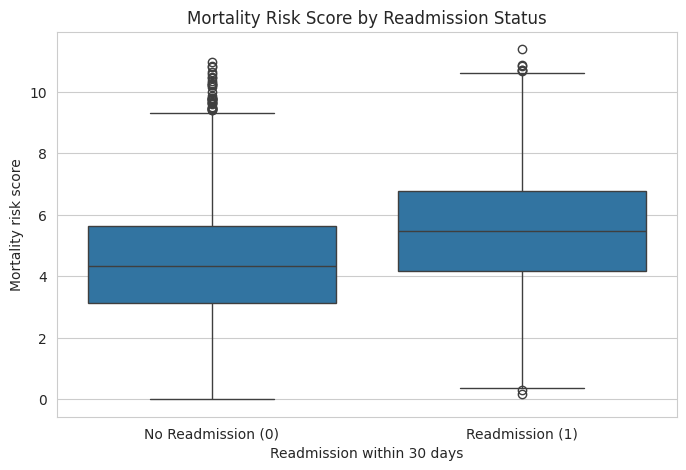

In [15]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='readmission_30d', y='mortality_risk_score', data=df_model)
plt.title("Mortality Risk Score by Readmission Status")
plt.xlabel("Readmission within 30 days")
plt.ylabel("Mortality risk score")
plt.xticks([0, 1], ['No Readmission (0)', 'Readmission (1)'])
plt.show()

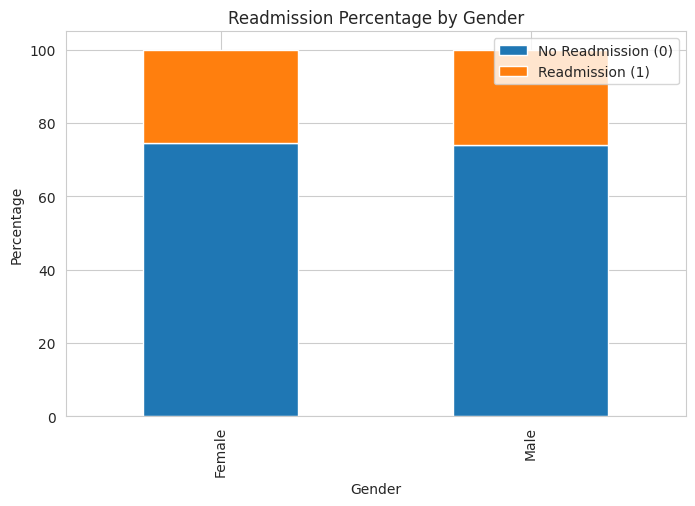

In [16]:
gender_readmit = pd.crosstab(df_model['gender'], df_model['readmission_30d'], normalize='index') * 100
gender_readmit.plot(kind='bar', stacked=True, figsize=(8, 5))

plt.title("Readmission Percentage by Gender")
plt.xlabel("Gender")
plt.ylabel("Percentage")
plt.legend(['No Readmission (0)', 'Readmission (1)'])
plt.show()

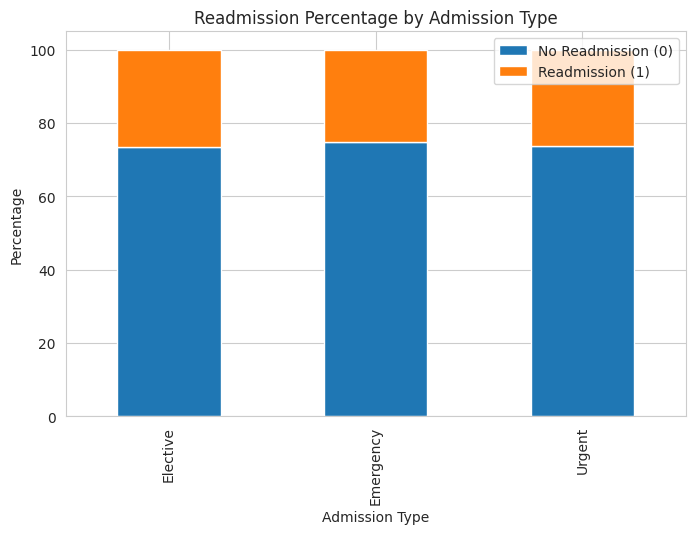

In [17]:
admission_readmit = pd.crosstab(df_model['admission_type'], df_model['readmission_30d'], normalize='index') * 100
admission_readmit.plot(kind='bar', stacked=True, figsize=(8, 5))

plt.title("Readmission Percentage by Admission Type")
plt.xlabel("Admission Type")
plt.ylabel("Percentage")
plt.legend(['No Readmission (0)', 'Readmission (1)'])
plt.show()

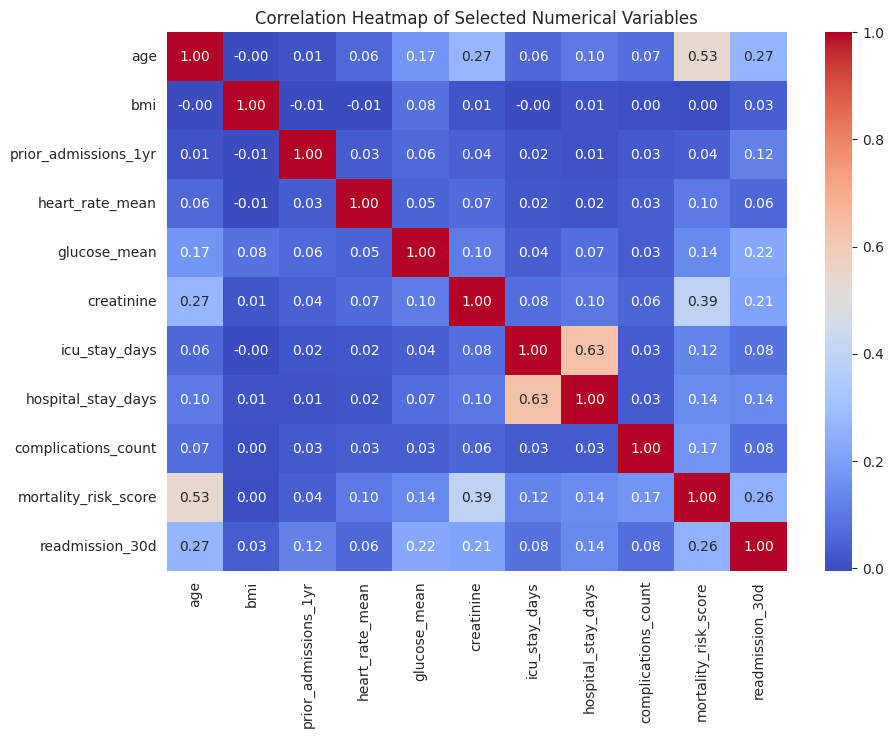

In [18]:
selected_num_cols = [
    'age', 'bmi', 'prior_admissions_1yr', 'heart_rate_mean',
    'glucose_mean', 'creatinine', 'icu_stay_days',
    'hospital_stay_days', 'complications_count',
    'mortality_risk_score', 'readmission_30d'
]

corr_matrix = df_model[selected_num_cols].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap of Selected Numerical Variables")
plt.show()

**Feature Engineering and Model Preparation**

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True) * 100)

X_train shape: (9600, 37)
X_test shape: (2400, 37)
y_train shape: (9600,)
y_test shape: (2400,)

Training target distribution:
readmission_30d
0    74.354167
1    25.645833
Name: proportion, dtype: float64

Testing target distribution:
readmission_30d
0    74.375
1    25.625
Name: proportion, dtype: float64


In [20]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Numerical preprocessing
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

# Categorical preprocessing
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Combined preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

print("Preprocessor created successfully.")

Preprocessor created successfully.


In [21]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed X_train shape:", X_train_processed.shape)
print("Processed X_test shape:", X_test_processed.shape)

Processed X_train shape: (9600, 51)
Processed X_test shape: (2400, 51)


In [22]:
encoded_cat_features = preprocessor.named_transformers_['cat']['onehot'].get_feature_names_out(categorical_cols)
all_feature_names = numerical_cols + list(encoded_cat_features)

print("Total transformed feature count:", len(all_feature_names))
print("\nFirst 20 transformed feature names:")
print(all_feature_names[:20])

Total transformed feature count: 51

First 20 transformed feature names:
['age', 'bmi', 'prior_admissions_1yr', 'diabetes', 'hypertension', 'cad', 'ckd', 'copd', 'sepsis_history', 'heart_rate_mean', 'systolic_bp_mean', 'respiratory_rate_mean', 'spo2_mean', 'temperature_mean', 'glucose_mean', 'creatinine', 'bun', 'sodium', 'potassium', 'hemoglobin']


In [23]:
print("Training class counts:")
print(y_train.value_counts())

print("\nTraining class percentages:")
print(y_train.value_counts(normalize=True) * 100)

Training class counts:
readmission_30d
0    7138
1    2462
Name: count, dtype: int64

Training class percentages:
readmission_30d
0    74.354167
1    25.645833
Name: proportion, dtype: float64


**Logistic Regression model**

In [24]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)

lr_model.fit(X_train_processed, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [25]:
y_pred_lr = lr_model.predict(X_test_processed)
y_prob_lr = lr_model.predict_proba(X_test_processed)[:, 1]

print("Predictions generated successfully.")
print("Predicted class labels shape:", y_pred_lr.shape)
print("Predicted probabilities shape:", y_prob_lr.shape)

Predictions generated successfully.
Predicted class labels shape: (2400,)
Predicted probabilities shape: (2400,)


In [26]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, matthews_corrcoef,
    classification_report
)

print("Logistic Regression Performance:\n")

print("Accuracy:", round(accuracy_score(y_test, y_pred_lr), 4))
print("Precision:", round(precision_score(y_test, y_pred_lr), 4))
print("Recall:", round(recall_score(y_test, y_pred_lr), 4))
print("F1-score:", round(f1_score(y_test, y_pred_lr), 4))
print("ROC-AUC:", round(roc_auc_score(y_test, y_prob_lr), 4))
print("PR-AUC:", round(average_precision_score(y_test, y_prob_lr), 4))
print("MCC:", round(matthews_corrcoef(y_test, y_pred_lr), 4))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_lr))

Logistic Regression Performance:

Accuracy: 0.7033
Precision: 0.4509
Recall: 0.7236
F1-score: 0.5556
ROC-AUC: 0.7772
PR-AUC: 0.5813
MCC: 0.3726

Classification Report:

              precision    recall  f1-score   support

           0       0.88      0.70      0.78      1785
           1       0.45      0.72      0.56       615

    accuracy                           0.70      2400
   macro avg       0.67      0.71      0.67      2400
weighted avg       0.77      0.70      0.72      2400



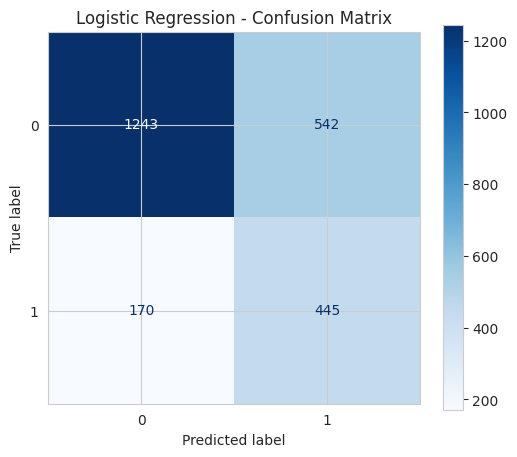

In [27]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr, cmap='Blues', ax=ax)
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

**Random Forest**

In [28]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_processed, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [29]:
y_pred_rf = rf_model.predict(X_test_processed)
y_prob_rf = rf_model.predict_proba(X_test_processed)[:, 1]

print("Random Forest predictions generated successfully.")
print("Predicted class labels shape:", y_pred_rf.shape)
print("Predicted probabilities shape:", y_prob_rf.shape)

Random Forest predictions generated successfully.
Predicted class labels shape: (2400,)
Predicted probabilities shape: (2400,)


In [30]:
print("Random Forest Performance:\n")

print("Accuracy:", round(accuracy_score(y_test, y_pred_rf), 4))
print("Precision:", round(precision_score(y_test, y_pred_rf), 4))
print("Recall:", round(recall_score(y_test, y_pred_rf), 4))
print("F1-score:", round(f1_score(y_test, y_pred_rf), 4))
print("ROC-AUC:", round(roc_auc_score(y_test, y_prob_rf), 4))
print("PR-AUC:", round(average_precision_score(y_test, y_prob_rf), 4))
print("MCC:", round(matthews_corrcoef(y_test, y_pred_rf), 4))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))

Random Forest Performance:

Accuracy: 0.7454
Precision: 0.5029
Recall: 0.5593
F1-score: 0.5296
ROC-AUC: 0.7607
PR-AUC: 0.5502
MCC: 0.3567

Classification Report:

              precision    recall  f1-score   support

           0       0.84      0.81      0.83      1785
           1       0.50      0.56      0.53       615

    accuracy                           0.75      2400
   macro avg       0.67      0.68      0.68      2400
weighted avg       0.76      0.75      0.75      2400



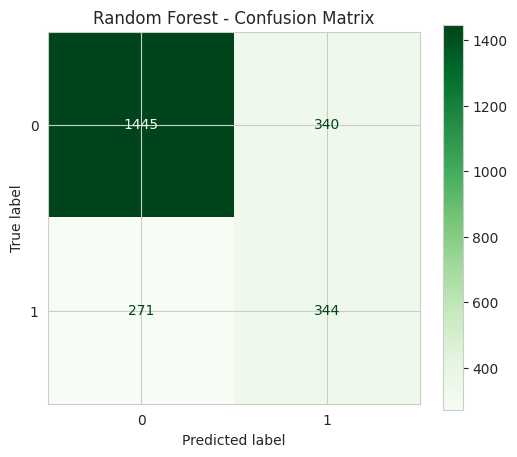

In [31]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, cmap='Greens', ax=ax)
plt.title("Random Forest - Confusion Matrix")
plt.show()

**XGBoost**

In [32]:
from xgboost import XGBClassifier

In [33]:
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42
)

xgb_model.fit(X_train_processed, y_train)

print("XGBoost model trained successfully.")

XGBoost model trained successfully.


In [34]:
y_pred_xgb = xgb_model.predict(X_test_processed)
y_prob_xgb = xgb_model.predict_proba(X_test_processed)[:, 1]

print("XGBoost predictions generated successfully.")
print("Predicted class labels shape:", y_pred_xgb.shape)
print("Predicted probabilities shape:", y_prob_xgb.shape)

XGBoost predictions generated successfully.
Predicted class labels shape: (2400,)
Predicted probabilities shape: (2400,)


In [35]:
print("XGBoost Performance:\n")

print("Accuracy:", round(accuracy_score(y_test, y_pred_xgb), 4))
print("Precision:", round(precision_score(y_test, y_pred_xgb), 4))
print("Recall:", round(recall_score(y_test, y_pred_xgb), 4))
print("F1-score:", round(f1_score(y_test, y_pred_xgb), 4))
print("ROC-AUC:", round(roc_auc_score(y_test, y_prob_xgb), 4))
print("PR-AUC:", round(average_precision_score(y_test, y_prob_xgb), 4))
print("MCC:", round(matthews_corrcoef(y_test, y_pred_xgb), 4))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_xgb))

XGBoost Performance:

Accuracy: 0.7738
Precision: 0.6241
Recall: 0.2943
F1-score: 0.4
ROC-AUC: 0.7572
PR-AUC: 0.5322
MCC: 0.3124

Classification Report:

              precision    recall  f1-score   support

           0       0.79      0.94      0.86      1785
           1       0.62      0.29      0.40       615

    accuracy                           0.77      2400
   macro avg       0.71      0.62      0.63      2400
weighted avg       0.75      0.77      0.74      2400



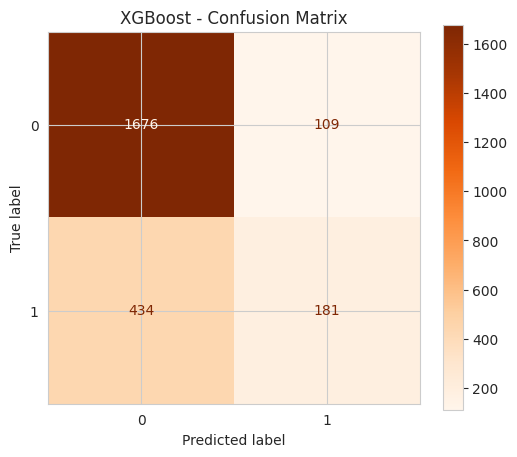

In [36]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_xgb, cmap='Oranges', ax=ax)
plt.title("XGBoost - Confusion Matrix")
plt.show()

**Final Model Comparison**

In [37]:
comparison_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb)
    ],
    'Precision': [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_xgb)
    ],
    'Recall': [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_xgb)
    ],
    'F1-score': [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_xgb)
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_xgb)
    ],
    'PR-AUC': [
        average_precision_score(y_test, y_prob_lr),
        average_precision_score(y_test, y_prob_rf),
        average_precision_score(y_test, y_prob_xgb)
    ],
    'MCC': [
        matthews_corrcoef(y_test, y_pred_lr),
        matthews_corrcoef(y_test, y_pred_rf),
        matthews_corrcoef(y_test, y_pred_xgb)
    ]
})

comparison_df = comparison_df.round(4)
display(comparison_df)

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC,MCC
0,Logistic Regression,0.7033,0.4509,0.7236,0.5556,0.7772,0.5813,0.3726
1,Random Forest,0.7454,0.5029,0.5593,0.5296,0.7607,0.5502,0.3567
2,XGBoost,0.7738,0.6241,0.2943,0.4000,0.7572,0.5322,0.3124


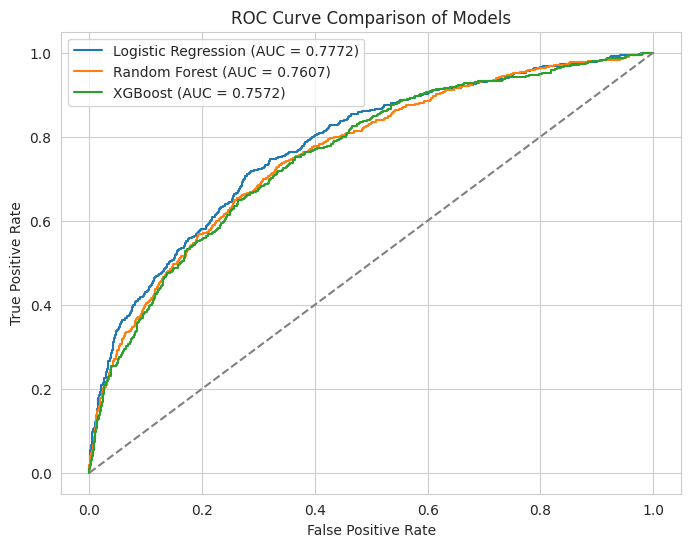

In [38]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(8, 6))

# Logistic Regression
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {roc_auc_score(y_test, y_prob_lr):.4f})')

# Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_score(y_test, y_prob_rf):.4f})')

# XGBoost
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {roc_auc_score(y_test, y_prob_xgb):.4f})')

plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison of Models')
plt.legend()
plt.show()

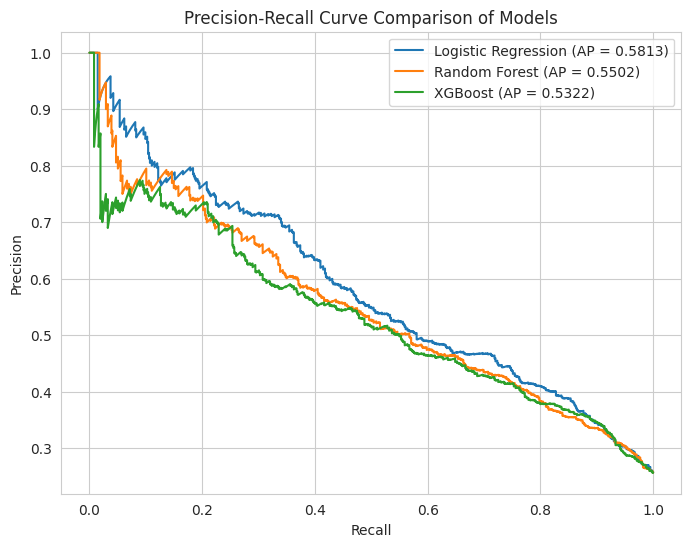

In [39]:
from sklearn.metrics import precision_recall_curve

plt.figure(figsize=(8, 6))

# Logistic Regression
precision_lr, recall_lr, _ = precision_recall_curve(y_test, y_prob_lr)
plt.plot(recall_lr, precision_lr, label=f'Logistic Regression (AP = {average_precision_score(y_test, y_prob_lr):.4f})')

# Random Forest
precision_rf, recall_rf, _ = precision_recall_curve(y_test, y_prob_rf)
plt.plot(recall_rf, precision_rf, label=f'Random Forest (AP = {average_precision_score(y_test, y_prob_rf):.4f})')

# XGBoost
precision_xgb, recall_xgb, _ = precision_recall_curve(y_test, y_prob_xgb)
plt.plot(recall_xgb, precision_xgb, label=f'XGBoost (AP = {average_precision_score(y_test, y_prob_xgb):.4f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve Comparison of Models')
plt.legend()
plt.show()

In [40]:
comparison_df.to_csv('/content/drive/MyDrive/eICU/model_comparison_results.csv', index=False)
print("Model comparison table saved successfully.")

Model comparison table saved successfully.


**CatBoost**

In [42]:
!pip install catboost -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.8 MB/s eta 0:00:00


In [43]:
from catboost import CatBoostClassifier

In [44]:
cat_feature_indices = [X_train.columns.get_loc(col) for col in categorical_cols]

print("Categorical feature indices:", cat_feature_indices)
print("Categorical columns:", categorical_cols)

Categorical feature indices: [1, 2, 4, 5, 36]
Categorical columns: ['gender', 'ethnicity', 'admission_type', 'unit_type', 'discharge_disposition']


In [45]:
cat_model = CatBoostClassifier(
    iterations=300,
    depth=6,
    learning_rate=0.05,
    loss_function='Logloss',
    eval_metric='AUC',
    random_seed=42,
    verbose=0,
    class_weights=[1, 7138/2462]
)

cat_model.fit(
    X_train, y_train,
    cat_features=cat_feature_indices
)

print("CatBoost model trained successfully.")

CatBoost model trained successfully.


In [46]:
y_pred_cat = cat_model.predict(X_test)
y_pred_cat = y_pred_cat.astype(int)

y_prob_cat = cat_model.predict_proba(X_test)[:, 1]

print("CatBoost predictions generated successfully.")
print("Predicted class labels shape:", y_pred_cat.shape)
print("Predicted probabilities shape:", y_prob_cat.shape)

CatBoost predictions generated successfully.
Predicted class labels shape: (2400,)
Predicted probabilities shape: (2400,)


In [47]:
print("CatBoost Performance:\n")

print("Accuracy:", round(accuracy_score(y_test, y_pred_cat), 4))
print("Precision:", round(precision_score(y_test, y_pred_cat), 4))
print("Recall:", round(recall_score(y_test, y_pred_cat), 4))
print("F1-score:", round(f1_score(y_test, y_pred_cat), 4))
print("ROC-AUC:", round(roc_auc_score(y_test, y_prob_cat), 4))
print("PR-AUC:", round(average_precision_score(y_test, y_prob_cat), 4))
print("MCC:", round(matthews_corrcoef(y_test, y_pred_cat), 4))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_cat))

CatBoost Performance:

Accuracy: 0.7021
Precision: 0.4454
Recall: 0.6634
F1-score: 0.533
ROC-AUC: 0.7626
PR-AUC: 0.5627
MCC: 0.3404

Classification Report:

              precision    recall  f1-score   support

           0       0.86      0.72      0.78      1785
           1       0.45      0.66      0.53       615

    accuracy                           0.70      2400
   macro avg       0.65      0.69      0.66      2400
weighted avg       0.75      0.70      0.72      2400



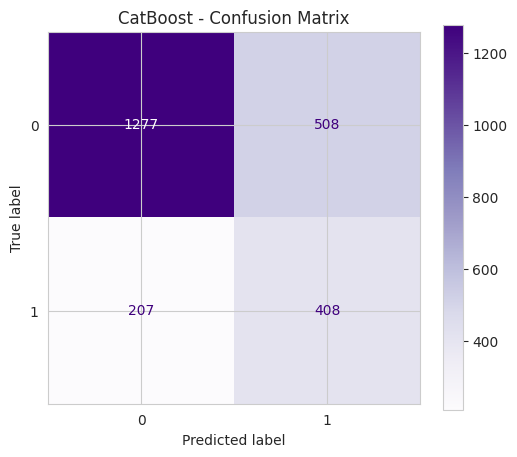

In [48]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_cat, cmap='Purples', ax=ax)
plt.title("CatBoost - Confusion Matrix")
plt.show()

LightGBM

In [50]:
!pip install lightgbm -q
from lightgbm import LGBMClassifier

In [51]:
lgbm_model = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    num_leaves=31,
    class_weight='balanced',
    random_state=42
)

lgbm_model.fit(X_train_processed, y_train)

print("LightGBM model trained successfully.")

[LightGBM] [Info] Number of positive: 2462, number of negative: 7138
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002692 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3568
[LightGBM] [Info] Number of data points in the train set: 9600, number of used features: 51
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: 

In [52]:
y_pred_lgbm = lgbm_model.predict(X_test_processed)
y_prob_lgbm = lgbm_model.predict_proba(X_test_processed)[:, 1]

print("LightGBM predictions generated successfully.")
print("Predicted class labels shape:", y_pred_lgbm.shape)
print("Predicted probabilities shape:", y_prob_lgbm.shape)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM predictions generated successfully.
Predicted class labels shape: (2400,)
Predicted probabilities shape: (2400,)


In [53]:
print("LightGBM Performance:\n")

print("Accuracy:", round(accuracy_score(y_test, y_pred_lgbm), 4))
print("Precision:", round(precision_score(y_test, y_pred_lgbm), 4))
print("Recall:", round(recall_score(y_test, y_pred_lgbm), 4))
print("F1-score:", round(f1_score(y_test, y_pred_lgbm), 4))
print("ROC-AUC:", round(roc_auc_score(y_test, y_prob_lgbm), 4))
print("PR-AUC:", round(average_precision_score(y_test, y_prob_lgbm), 4))
print("MCC:", round(matthews_corrcoef(y_test, y_pred_lgbm), 4))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_lgbm))

LightGBM Performance:

Accuracy: 0.7175
Precision: 0.4592
Recall: 0.5772
F1-score: 0.5115
ROC-AUC: 0.7475
PR-AUC: 0.5301
MCC: 0.3205

Classification Report:

              precision    recall  f1-score   support

           0       0.84      0.77      0.80      1785
           1       0.46      0.58      0.51       615

    accuracy                           0.72      2400
   macro avg       0.65      0.67      0.66      2400
weighted avg       0.74      0.72      0.73      2400



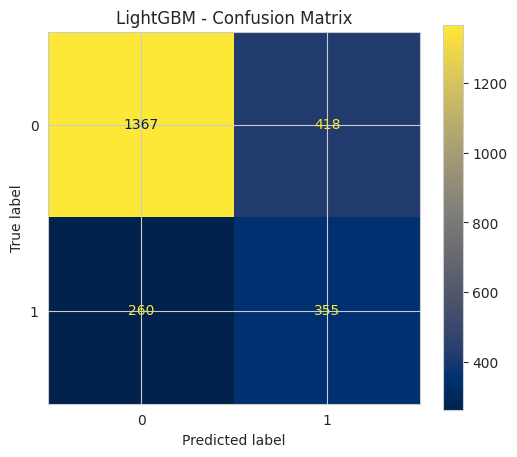

In [54]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lgbm, cmap='cividis', ax=ax)
plt.title("LightGBM - Confusion Matrix")
plt.show()

**Comparison Table for All 5 Models**

In [55]:
final_comparison_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost', 'CatBoost', 'LightGBM'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb),
        accuracy_score(y_test, y_pred_cat),
        accuracy_score(y_test, y_pred_lgbm)
    ],
    'Precision': [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_xgb),
        precision_score(y_test, y_pred_cat),
        precision_score(y_test, y_pred_lgbm)
    ],
    'Recall': [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_xgb),
        recall_score(y_test, y_pred_cat),
        recall_score(y_test, y_pred_lgbm)
    ],
    'F1-score': [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_xgb),
        f1_score(y_test, y_pred_cat),
        f1_score(y_test, y_pred_lgbm)
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_xgb),
        roc_auc_score(y_test, y_prob_cat),
        roc_auc_score(y_test, y_prob_lgbm)
    ],
    'PR-AUC': [
        average_precision_score(y_test, y_prob_lr),
        average_precision_score(y_test, y_prob_rf),
        average_precision_score(y_test, y_prob_xgb),
        average_precision_score(y_test, y_prob_cat),
        average_precision_score(y_test, y_prob_lgbm)
    ],
    'MCC': [
        matthews_corrcoef(y_test, y_pred_lr),
        matthews_corrcoef(y_test, y_pred_rf),
        matthews_corrcoef(y_test, y_pred_xgb),
        matthews_corrcoef(y_test, y_pred_cat),
        matthews_corrcoef(y_test, y_pred_lgbm)
    ]
})

final_comparison_df = final_comparison_df.round(4)
display(final_comparison_df)

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC,MCC
0,Logistic Regression,0.7033,0.4509,0.7236,0.5556,0.7772,0.5813,0.3726
1,Random Forest,0.7454,0.5029,0.5593,0.5296,0.7607,0.5502,0.3567
2,XGBoost,0.7738,0.6241,0.2943,0.4000,0.7572,0.5322,0.3124
3,CatBoost,0.7021,0.4454,0.6634,0.5330,0.7626,0.5627,0.3404
4,LightGBM,0.7175,0.4592,0.5772,0.5115,0.7475,0.5301,0.3205


In [56]:
print("Models ranked by Recall:\n")
display(final_comparison_df.sort_values(by='Recall', ascending=False).reset_index(drop=True))

Models ranked by Recall:



,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC,MCC
0,Logistic Regression,0.7033,0.4509,0.7236,0.5556,0.7772,0.5813,0.3726
1,CatBoost,0.7021,0.4454,0.6634,0.5330,0.7626,0.5627,0.3404
2,LightGBM,0.7175,0.4592,0.5772,0.5115,0.7475,0.5301,0.3205
3,Random Forest,0.7454,0.5029,0.5593,0.5296,0.7607,0.5502,0.3567
4,XGBoost,0.7738,0.6241,0.2943,0.4000,0.7572,0.5322,0.3124


In [57]:
print("Models ranked by ROC-AUC:\n")
display(final_comparison_df.sort_values(by='ROC-AUC', ascending=False).reset_index(drop=True))

Models ranked by ROC-AUC:



,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC,MCC
0,Logistic Regression,0.7033,0.4509,0.7236,0.5556,0.7772,0.5813,0.3726
1,CatBoost,0.7021,0.4454,0.6634,0.5330,0.7626,0.5627,0.3404
2,Random Forest,0.7454,0.5029,0.5593,0.5296,0.7607,0.5502,0.3567
3,XGBoost,0.7738,0.6241,0.2943,0.4000,0.7572,0.5322,0.3124
4,LightGBM,0.7175,0.4592,0.5772,0.5115,0.7475,0.5301,0.3205


In [58]:
print("Models ranked by MCC:\n")
display(final_comparison_df.sort_values(by='MCC', ascending=False).reset_index(drop=True))

Models ranked by MCC:



,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC,MCC
0,Logistic Regression,0.7033,0.4509,0.7236,0.5556,0.7772,0.5813,0.3726
1,Random Forest,0.7454,0.5029,0.5593,0.5296,0.7607,0.5502,0.3567
2,CatBoost,0.7021,0.4454,0.6634,0.5330,0.7626,0.5627,0.3404
3,LightGBM,0.7175,0.4592,0.5772,0.5115,0.7475,0.5301,0.3205
4,XGBoost,0.7738,0.6241,0.2943,0.4000,0.7572,0.5322,0.3124


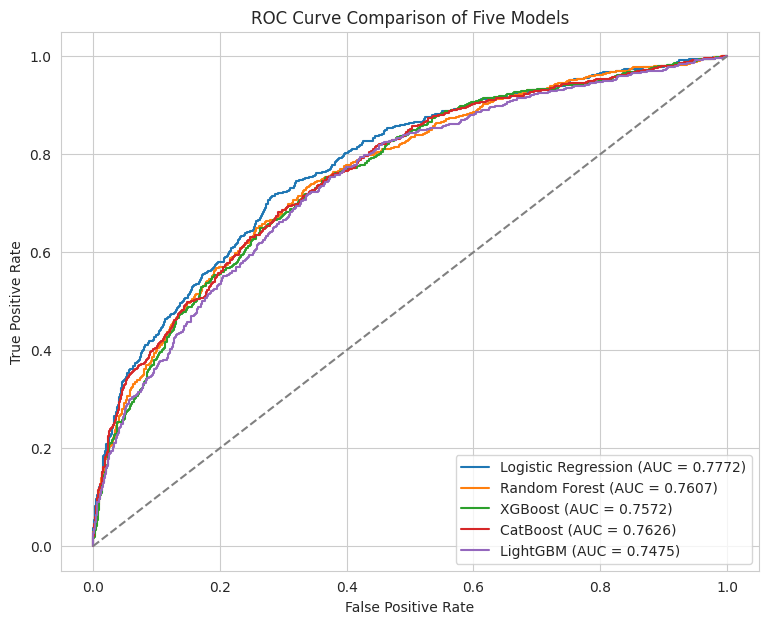

In [59]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 7))

# Logistic Regression
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {roc_auc_score(y_test, y_prob_lr):.4f})')

# Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_score(y_test, y_prob_rf):.4f})')

# XGBoost
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {roc_auc_score(y_test, y_prob_xgb):.4f})')

# CatBoost
fpr_cat, tpr_cat, _ = roc_curve(y_test, y_prob_cat)
plt.plot(fpr_cat, tpr_cat, label=f'CatBoost (AUC = {roc_auc_score(y_test, y_prob_cat):.4f})')

# LightGBM
fpr_lgbm, tpr_lgbm, _ = roc_curve(y_test, y_prob_lgbm)
plt.plot(fpr_lgbm, tpr_lgbm, label=f'LightGBM (AUC = {roc_auc_score(y_test, y_prob_lgbm):.4f})')

plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison of Five Models')
plt.legend()
plt.show()

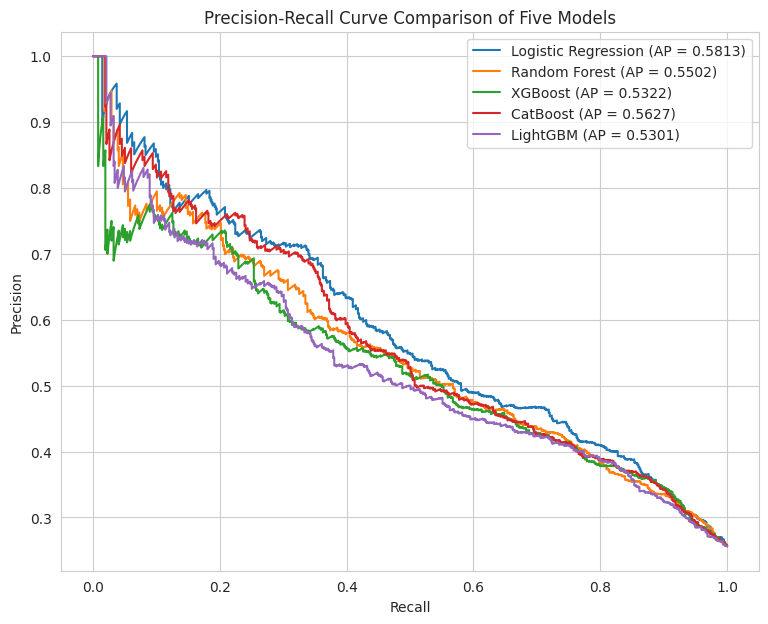

In [60]:
from sklearn.metrics import precision_recall_curve

plt.figure(figsize=(9, 7))

# Logistic Regression
precision_lr, recall_lr, _ = precision_recall_curve(y_test, y_prob_lr)
plt.plot(recall_lr, precision_lr, label=f'Logistic Regression (AP = {average_precision_score(y_test, y_prob_lr):.4f})')

# Random Forest
precision_rf, recall_rf, _ = precision_recall_curve(y_test, y_prob_rf)
plt.plot(recall_rf, precision_rf, label=f'Random Forest (AP = {average_precision_score(y_test, y_prob_rf):.4f})')

# XGBoost
precision_xgb, recall_xgb, _ = precision_recall_curve(y_test, y_prob_xgb)
plt.plot(recall_xgb, precision_xgb, label=f'XGBoost (AP = {average_precision_score(y_test, y_prob_xgb):.4f})')

# CatBoost
precision_cat, recall_cat, _ = precision_recall_curve(y_test, y_prob_cat)
plt.plot(recall_cat, precision_cat, label=f'CatBoost (AP = {average_precision_score(y_test, y_prob_cat):.4f})')

# LightGBM
precision_lgbm, recall_lgbm, _ = precision_recall_curve(y_test, y_prob_lgbm)
plt.plot(recall_lgbm, precision_lgbm, label=f'LightGBM (AP = {average_precision_score(y_test, y_prob_lgbm):.4f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve Comparison of Five Models')
plt.legend()
plt.show()

In [61]:
final_comparison_df.to_csv('/content/drive/MyDrive/eICU/final_model_comparison_5_models.csv', index=False)
print("Final comparison table saved successfully.")

Final comparison table saved successfully.


In [62]:
prediction_results_df = pd.DataFrame({
    'Actual': y_test.values,
    'LR_Pred': y_pred_lr,
    'LR_Prob': y_prob_lr,
    'RF_Pred': y_pred_rf,
    'RF_Prob': y_prob_rf,
    'XGB_Pred': y_pred_xgb,
    'XGB_Prob': y_prob_xgb,
    'CAT_Pred': y_pred_cat,
    'CAT_Prob': y_prob_cat,
    'LGBM_Pred': y_pred_lgbm,
    'LGBM_Prob': y_prob_lgbm
})

display(prediction_results_df.head())

,Actual,LR_Pred,LR_Prob,RF_Pred,RF_Prob,XGB_Pred,XGB_Prob,CAT_Pred,CAT_Prob,LGBM_Pred,LGBM_Prob
0,0,0,0.081747,0,0.121574,0,0.017585,0,0.081825,0,0.074375
1,0,0,0.411689,0,0.425629,0,0.173451,0,0.403525,0,0.321944
2,0,0,0.314695,0,0.310715,0,0.093980,0,0.209054,0,0.106665
3,0,0,0.398137,0,0.386216,0,0.150636,0,0.361919,0,0.262515
4,0,0,0.253159,0,0.326130,0,0.081723,0,0.278474,0,0.111282


In [63]:
prediction_results_df.to_csv('/content/drive/MyDrive/eICU/final_test_predictions_all_models.csv', index=False)
print("Prediction results saved successfully.")

Prediction results saved successfully.


In [64]:
best_recall_model = final_comparison_df.loc[final_comparison_df['Recall'].idxmax(), 'Model']
best_auc_model = final_comparison_df.loc[final_comparison_df['ROC-AUC'].idxmax(), 'Model']
best_prauc_model = final_comparison_df.loc[final_comparison_df['PR-AUC'].idxmax(), 'Model']
best_mcc_model = final_comparison_df.loc[final_comparison_df['MCC'].idxmax(), 'Model']

print("Best model by Recall:", best_recall_model)
print("Best model by ROC-AUC:", best_auc_model)
print("Best model by PR-AUC:", best_prauc_model)
print("Best model by MCC:", best_mcc_model)

Best model by Recall: Logistic Regression
Best model by ROC-AUC: Logistic Regression
Best model by PR-AUC: Logistic Regression
Best model by MCC: Logistic Regression


In [65]:
lgbm_importance_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': lgbm_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

display(lgbm_importance_df.head(20))

,Feature,Importance
14,glucose_mean,507
0,age,441
29,hospital_stay_days,434
9,heart_rate_mean,422
15,creatinine,408
19,hemoglobin,408
1,bmi,407
20,wbc,400
16,bun,382
11,respiratory_rate_mean,378


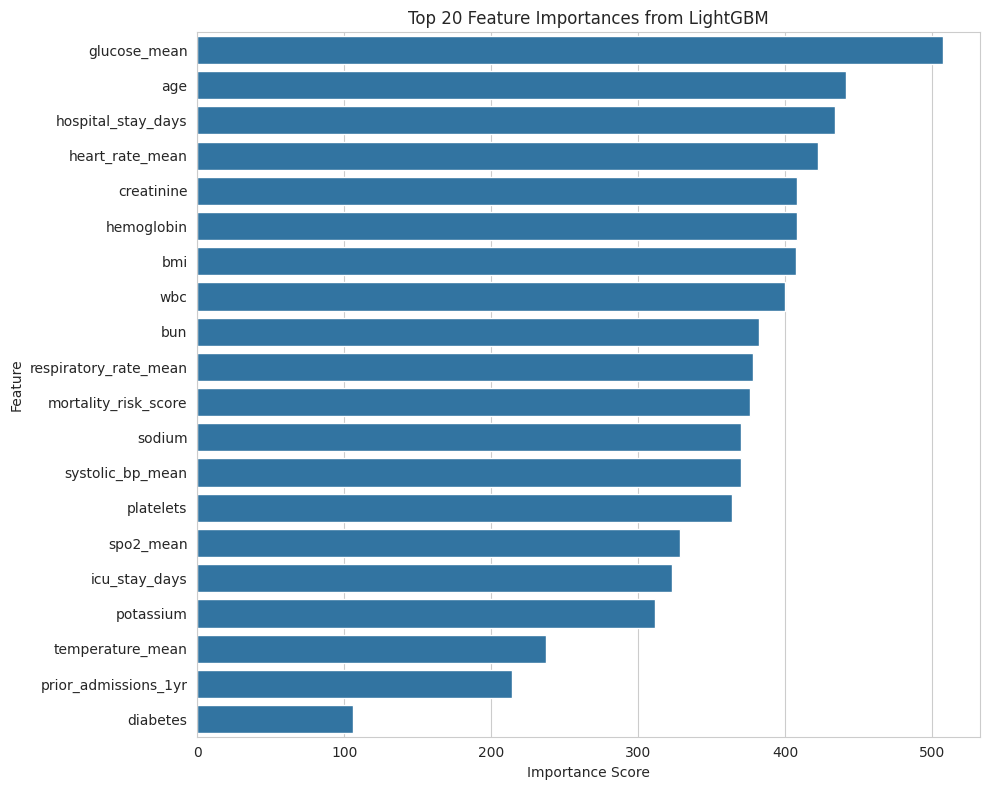

In [66]:
import matplotlib.pyplot as plt
import seaborn as sns

# top 20 features
top20_lgbm = lgbm_importance_df.head(20)

plt.figure(figsize=(10, 8))
sns.barplot(
    data=top20_lgbm,
    x='Importance',
    y='Feature'
)
plt.title('Top 20 Feature Importances from LightGBM')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()